In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
from scipy import stats

In [2]:
alpha = '\N{GREEK SMALL LETTER ALPHA}'


### Problem 1

In [3]:
df_01 = pd.DataFrame({
    'treatment': np.repeat(np.arange(4)+1,4),
    'strength': [3129,3000,2865,2890,3200,3300,2975,3150,2800,2900,2985,3050,2600,2700,2600,2765]
})


a. statistical analysis
* null hypothesis ($H_0$): mixing techniques affect the strength of the cement
* alternative hypothesis ($H_1$): mixing techniques do not affect the strength of the cement
* $\alpha = 0.05$

In [4]:
df_01['t_ave'] = df_01.groupby('treatment')['strength'].transform('mean')
df_01['ave'] = df_01['strength'].mean()
df_01['t_dev'] = df_01['t_ave'] - df_01['ave']
df_01['residual'] = df_01['strength'] - df_01['t_ave']


In [5]:
# sum of squares of residuals with 16-4 degrees of freedom
SSE_01 = (df_01['residual']**2).sum()
# Mean square of residuals
MSE_01 = SSE_01/12
# sum of squares of treatment deviations with 4-1 degrees of freedom
SST_01 = (df_01['t_dev']**2).sum()
# mean square of treatment deviations
MST_01 = SST_01/3

# F statistic
F_01 = MST_01 / MSE_01
# p value
p_01 = stats.f.sf(F_01, dfn=3, dfd=12)
print(f'the p value for the test is {p_01.round(3)}, smaller than the pre selected {alpha}=0.05. the null hypothesis is safe to reject')

the p value for the test is 0.0, smaller than the pre selected α=0.05. the null hypothesis is safe to reject


b. graphical display of the data

conclusion: treatment 2 / 4 increase / decrease the tensile strength significantly

In [6]:
# generate data to plot the t statistic distribution
loc_01 = df_01['strength'].mean()
scale_01 = np.sqrt(MSE_01/4)
dof_01 = 12 # inherent from MSE_01
range_01 = 3 * scale_01

x_01 = np.linspace(-range_01,range_01,1001)+loc_01
y_01 = stats.t.pdf(x_01,loc=loc_01, scale=scale_01, df=dof_01)

[Text(2971.0, 0.0002, '1'),
 Text(3156.25, 0.0002, '2'),
 Text(2933.75, 0.0002, '3'),
 Text(2666.25, 0.0002, '4')]

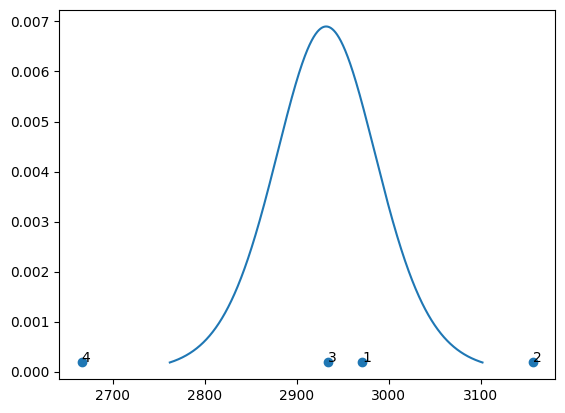

In [7]:
plt.plot(x_01, y_01)
plt.scatter(df_01.groupby('treatment')['strength'].mean().values, [0.0002]*4)
[plt.text(x,y,s) for x,y,s in zip(df_01.groupby('treatment')['strength'].mean().values, [0.0002]*4, df_01.groupby('treatment')['strength'].mean().index)]

c. The Fisher Least Significant Difference (LSD) Method
$$LSD = t_{\alpha/2, N-a}  \sqrt{MS_E(\frac{1}{n_i} + \frac{1}{n_i})}$$

In [8]:
LSD_01 = stats.t.sf(0.025,df=12) * np.sqrt(MSE_01*(1/4+1/4))
LSD_01

np.float64(39.25796852380329)

In [9]:
df_01.groupby('treatment')['strength'].mean()[[1,2]].diff()

treatment
1       NaN
2    185.25
Name: strength, dtype: float64

In [10]:
diff_comb_01 = []
from itertools import combinations
diff_comb_01.extend(combinations([1,2,3,4],2))

diff_comb_01

[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

 The least significant difference is 39.258.
The difference between treatment 1 and 2 is 185.25.

 The least significant difference is 39.258.
The difference between treatment 1 and 3 is 37.25.

 The least significant difference is 39.258.
The difference between treatment 1 and 4 is 304.75.

 The least significant difference is 39.258.
The difference between treatment 2 and 3 is 222.5.

 The least significant difference is 39.258.
The difference between treatment 2 and 4 is 490.0.

 The least significant difference is 39.258.
The difference between treatment 3 and 4 is 267.5.



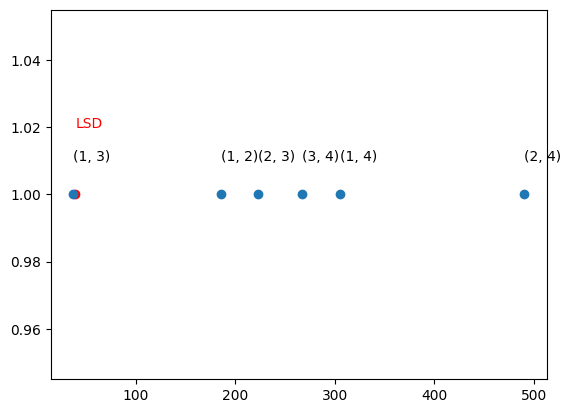

In [11]:
for i in diff_comb_01:
    print(f''' The least significant difference is {LSD_01.round(3)}.
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([LSD_01], [1], c='r')
plt.text(LSD_01, 1.02, 'LSD', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

d. Normality plot of the residuals

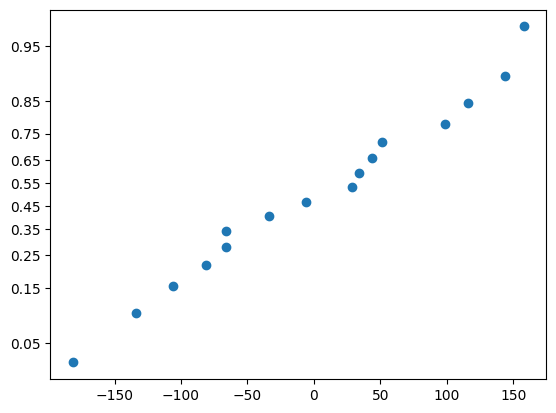

In [12]:
plt.scatter(df_01.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,17)[:-1]+1/32))
plt.yticks(-stats.norm.isf(np.linspace(0.05,0.95,10)), np.linspace(0.05,0.95,10).round(2))
plt.show() # no violation of normality

e. Residuals agains predicted tensile strength (the treatment means)

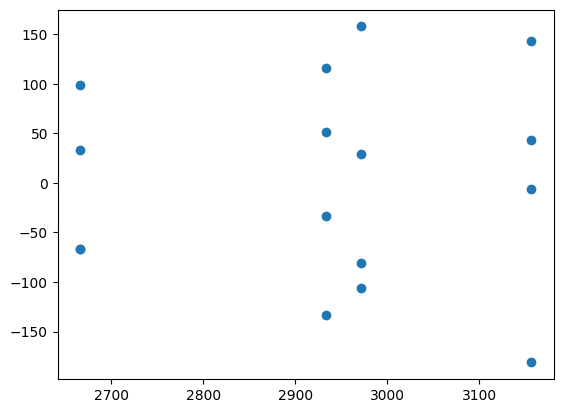

In [13]:
# plot residuals against treatment means
# The residuals are independent of the predicted tensile strengths
plt.scatter(df_01['ave'] + df_01['t_dev'], df_01['residual'])

f. Prepare a scatter plot of the results to aid the interpretation of the results of this experiment

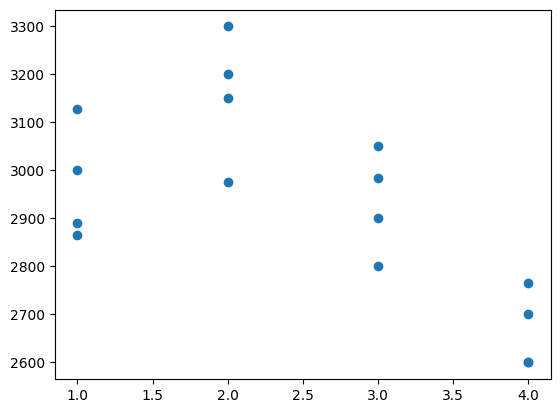

In [14]:
plt.scatter(df_01.treatment, df_01.strength)

# Problem 2
a. Duncan's multiple range test gives the same results as the Fisher Least Significance Method
* $\alpha = 0.05$
* the standard error of each treatment averages is 
$$S_t = \sqrt{\frac{MS_E}{n}}$$

In [15]:
# standard error of each treatment average
S_t_02 = np.sqrt(MSE_01/4)
r_2_02 = 3.08
r_3_02 = 3.23
r_4_02 = 3.33

In [16]:
R_2_02 = r_2_02 * S_t_02
R_3_02 = r_3_02 * S_t_02
R_4_02 = r_4_02 * S_t_02

The least significant ranges are 174.406, 182.9, and 188.562

The difference between treatment 1 and 2 is 185.25.


The difference between treatment 1 and 3 is 37.25.


The difference between treatment 1 and 4 is 304.75.


The difference between treatment 2 and 3 is 222.5.


The difference between treatment 2 and 4 is 490.0.


The difference between treatment 3 and 4 is 267.5.



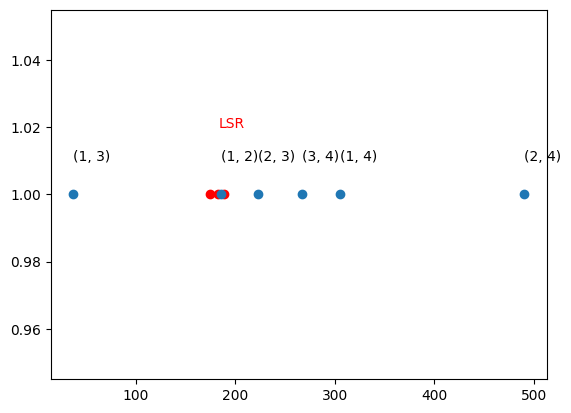

In [17]:
print(f'The least significant ranges are {R_2_02.round(3)}, {R_3_02.round(3)}, and {R_4_02.round(3)}')
for i in diff_comb_01:
    print(f'''
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([R_2_02, R_3_02, R_4_02], [1,1,1], c='r')
plt.text(R_3_02, 1.02, 'LSR', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

b. Tukey's test
* $\alpha = 0.05$ 
* the studentized range statistic
$$q = \frac{\bar{y}_{max} - \bar{y}_{min}}{\sqrt{MS_E/n}}$$
* For equal sample size
$$T_\alpha = q_\alpha(a,f) \sqrt{\frac{MS_E}{n}}$$
* For non-equal sample size
$$T_\alpha = \frac{q_\alpha(a,f)}{\sqrt{2}} \sqrt{MS_E(\frac{1}{n_i}+\frac{1}{n_j})}$$
* the $1-\alpha$ confidence interval,
$$\bar{y}_{i.} - \bar{y}_{j.} - T_\alpha \le \mu_i - \mu_j \le \bar{y}_{i.} - \bar{y}_{j.} + T_\alpha, i\ne j$$
* in this case, $\alpha=0.05$, degree of freedom $f=16-4=12$, and sample size is euqal $n=4$. the final result is different from Duncan's test and Fisher's test.

In [18]:
q_02 = 4.20
T_02 = q_02 * np.sqrt(MSE_01/4)

The Tukey's least significant difference is 237.826

The difference between treatment 1 and 2 is 185.25.


The difference between treatment 1 and 3 is 37.25.


The difference between treatment 1 and 4 is 304.75.


The difference between treatment 2 and 3 is 222.5.


The difference between treatment 2 and 4 is 490.0.


The difference between treatment 3 and 4 is 267.5.



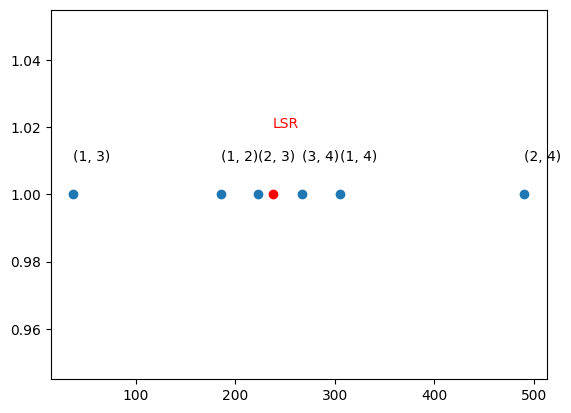

In [19]:
print(f'The Tukey\'s least significant difference is {T_02.round(3)}')
for i in diff_comb_01:
    print(f'''
The difference between treatment {i[0]} and {i[1]} is {np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff()).values[1].round(3)}.
''')
    
plt.scatter([T_02], [1], c='r')
plt.text(T_02, 1.02, 'LSR', c='r')
plt.scatter([np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]) for i in diff_comb_01] ,[1]*len(diff_comb_01))
for i in diff_comb_01:
    plt.text(np.abs(df_01.groupby('treatment')['strength'].mean()[list(i)].diff().values[1]), 1.01, i)

c. This is because Fisher least significant difference method and Duncan's method are more powerful in detecting true difference in means.

### Problem 3

In [20]:
# 95% confidence interval on the mean tensile strength using t statistic with a degree of freedom of (16-4)=12. Two tailed test
t_03 = stats.t.isf(0.025, scale=np.sqrt(MSE_01/4), df=12)

In [21]:
for i in range(4):
    print(f'The 95% confidence interval on the mean of treatment {i+1} is from {(df_01.groupby('treatment')['strength'].mean().values[i] - t_03).round(2)} to {(df_01.groupby('treatment')['strength'].mean().values[i] + t_03).round(2)}')

The 95% confidence interval on the mean of treatment 1 is from 2847.62 to 3094.38
The 95% confidence interval on the mean of treatment 2 is from 3032.87 to 3279.63
The 95% confidence interval on the mean of treatment 3 is from 2810.37 to 3057.13
The 95% confidence interval on the mean of treatment 4 is from 2542.87 to 2789.63


In [22]:
# find 95% confidence interval on the difference on means for treatment 1 and 3 using Tukey's test statistic
d13_03 = df_01.groupby('treatment')['strength'].mean()[[1,3]].diff(-1).values[0] #u1 - u3
d13_03

np.float64(37.25)

In [23]:
print(f'''
      The 95% confidence interval on the difference in means for treatment 1 and 3 is {(d13_03 - T_02).round(2)} to {(d13_03 + T_02).round(2)}.
      This range covers 0, meaning no significant difference btw 1 and 3 at a significant level of {alpha}=0.05
      ''')


      The 95% confidence interval on the difference in means for treatment 1 and 3 is -200.58 to 275.08.
      This range covers 0, meaning no significant difference btw 1 and 3 at a significant level of α=0.05
      


### Problem 4

In [24]:
df_04 = pd.DataFrame({
    'temp': [100]*5+[125]*4+[150]*5+[175]*4,
    'density': [21.8,21.9,21.7,21.6,21.7,21.7,21.4,21.5,21.4,21.9,21.8,21.8,21.6,21.5,21.9,21.7,21.8,21.4]
})

a. analysis of variance

In [25]:
df_04['ave'] = df_04['density'].mean()
df_04['t_ave'] = df_04.groupby('temp')['density'].transform('mean')
df_04['t_dev'] = df_04['t_ave'] - df_04['ave']
df_04['residual'] = df_04['density'] - df_04['t_ave']

In [26]:
SSE_04 = (df_04['residual']**2).sum() # sum of squares of residuals (within treatment deviations) with (18-4)=14 degrees of freedom
MSE_04 = SSE_04/14 # mean square, an estimate of standard deviation
SST_04 = (df_04['t_dev']**2).sum() # sum of squares of treatment deviations from grand average (btw treatment deviations) with (4-1)=3 degrees of freedom
MST_04 = SST_04/3 # mean square, an estimate of standard deviation btw treatments

# f statistic
f_04 = MST_04 / MSE_04

# p value of the test
p_04 = stats.f.sf(f_04, dfn=3, dfd=14)
print(f'The p value of the test is {p_04.round(3)}. There is no significant difference on the brick density from the temperature at the significance level of {alpha}=0.05')

The p value of the test is 0.157. There is no significant difference on the brick density from the temperature at the significance level of α=0.05


b. Yes it is. Duncan's multiple range test can be used for non-equal size samples.

c. check residuals
* The plot below shows there is no significant violation of normality assumption

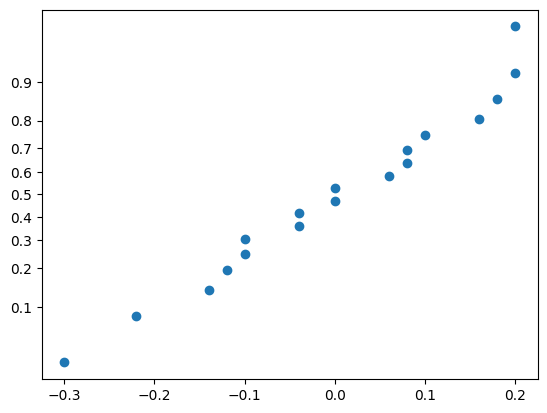

In [27]:
plt.scatter(df_04['residual'].sort_values(), -stats.norm.isf(np.linspace(0,1,19)[:-1]+1/36))
plt.yticks(-stats.norm.isf(np.linspace(0.1,0.9,9)), np.linspace(0.1,0.9,9).round(2))
plt.show()

d. the graphical display of the treatment means with the corresponding t distribution

The graphical display is consistent with the results of the analysis of variance in (a)

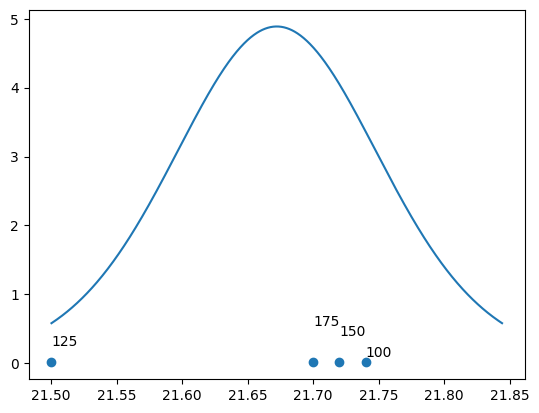

In [28]:
loc_04 = df_04['density'].mean() # the grand average
scale_04 = np.sqrt(MSE_04 / 4) # the standard error of the mean, used as the scale for the t test, the degree of freedom is 14, inherented from MSE_04
range_04 = stats.t.isf(0.025, scale=scale_04, df=14) # a mapping range corresponding to (1-0.05) or 95% confidence interval

x_04 = np.linspace(-range_04, range_04, 1001) # the mapping x
y_04 = stats.t.pdf(x_04, scale=scale_04, df=14) # the corresponding probability density for each x

plt.plot(x_04+loc_04, y_04)
plt.scatter(df_04.groupby('temp')['density'].mean(), [0.01]*4)
for i in range(4):
    plt.text(df_04.groupby('temp')['density'].mean().values[i], 0.1+0.15*i, df_04.groupby('temp')['density'].mean().index[i])
plt.show()

In [29]:
df_04.groupby('temp')['density'].mean()

temp
100    21.74
125    21.50
150    21.72
175    21.70
Name: density, dtype: float64

### Problem 5
The Fisher Least Significant Difference (LSD) Method for unequal sample sizes
$$LSD = t_{\alpha/2, N-a}  \sqrt{MS_E(\frac{1}{n_i} + \frac{1}{n_j})}, i\ne j$$

In [30]:
def fisher_lsd_05(n1, n2):
    return stats.t.isf(0.025,df=14)*np.sqrt(MSE_04*(1/n1+1/n2))

In [31]:
df_04.groupby('temp')['density'].mean()

temp
100    21.74
125    21.50
150    21.72
175    21.70
Name: density, dtype: float64

In [32]:
temp_04 = df_04.groupby('temp')['density'].mean().index.tolist() # all four temperatures (treatments)
temp_comb_04 = [] # create a list to store all temperature combinations (comparisons)
from itertools import combinations
temp_comb_04.extend(combinations(temp_04,2))
temp_comb_04

[(100, 125), (100, 150), (100, 175), (125, 150), (125, 175), (150, 175)]

In [33]:
for temp_comb in temp_comb_04:
    print(f'''
{temp_comb},
Absolute difference: {np.abs(df_04.groupby('temp')['density'].mean()[list(temp_comb)].diff().values[1]).round(3)},
Fisher least significant difference: {fisher_lsd_05((df_04['temp'] == temp_comb[0]).sum(),  (df_04['temp'] == temp_comb[1]).sum()).round(3)} 
''')


(100, 125),
Absolute difference: 0.24,
Fisher least significant difference: 0.231 


(100, 150),
Absolute difference: 0.02,
Fisher least significant difference: 0.218 


(100, 175),
Absolute difference: 0.04,
Fisher least significant difference: 0.231 


(125, 150),
Absolute difference: 0.22,
Fisher least significant difference: 0.231 


(125, 175),
Absolute difference: 0.2,
Fisher least significant difference: 0.243 


(150, 175),
Absolute difference: 0.02,
Fisher least significant difference: 0.231 



### Problem 6

In [34]:
df_06 = pd.DataFrame({
    'coating': np.repeat(np.arange(4)+1,4),
    'conductivity': [143,141,150,146,152,149,137,143,134,136,132,127,129,127,132,129]
})

a. analysis of variance to check if there is difference in conductivity due to coating type.
- null hypothesis ($H_0$): no difference, or btw treatment variance not larger than within treatment variance ($\sigma^2_T \le \sigma^2_{E}$)
- alternative hypothesis ($H_1$): significant difference, or btw treatment variance larger than within treatment variance ($\sigma^2_T > \sigma^2_{E}$)
- $\alpha=0.05$

In [35]:
df_06['ave'] = df_06['conductivity'].mean() # grand average
df_06['t_ave'] = df_06.groupby('coating')['conductivity'].transform('mean') # average of each coating type
df_06['residual'] = df_06['conductivity'] - df_06['t_ave'] # residual or within treatment deviations
df_06['t_dev'] = df_06['t_ave'] - df_06['ave'] # btw treatment deviations

SSE_06 = (df_06['residual']**2).sum() # sum of squares for residuals, 12 degrees of freedom
MSE_06 = SSE_06/12 # mean square for residuals, estimate of the test variance
SST_06 = (df_06['t_dev']**2).sum() # sum of squares for the btw treatment deviations, 3 degrees of freedom
MST_06 = SST_06/3 # mean square for treatment deviations, estimate of the treatment variance

f_06 = MST_06/MSE_06 # f statistic with 3 and 12 degrees of freedom
p_06 = stats.f.sf(f_06, dfn=3, dfd=12)

print(f'''
The p value for the test is {p_06.round(4)}, smaller than the pre-selected {alpha}=0.05. There is significant difference in conductivity due to coating type.      
''')


The p value for the test is 0.0003, smaller than the pre-selected α=0.05. There is significant difference in conductivity due to coating type.      



In [36]:
# b
print(f'The overall mean is {df_06['conductivity'].mean().round(1)}')
for i in range(4):
    print(f'The treatment effect of coating {i+1} is {df_06[df_06['coating']==i+1]['t_dev'].unique()[0]}')

The overall mean is 137.9
The treatment effect of coating 1 is 7.0625
The treatment effect of coating 2 is 7.3125
The treatment effect of coating 3 is -5.6875
The treatment effect of coating 4 is -8.6875


In [37]:
# c
# 95% confidence interval estimate of the mean of coating type 4
df_06[df_06['coating']==4]['t_ave'].unique()[0] # the mean of coating type 4
se_06c1 = np.sqrt(MSE_06/4) # the standard error of the mean of coating type 4, 12 degrees of freedom
t_06c1 = stats.t.isf(0.025,df=12) # t statistc, two tail test

print(f'The 95% confidence interval estimate of the mean of coating type 4 is from {(df_06[df_06['coating']==4]['t_ave'].unique()[0] - t_06c1*se_06c1).round(1)} to {(df_06[df_06['coating']==4]['t_ave'].unique()[0] + t_06c1*se_06c1).round(1)}')

The 95% confidence interval estimate of the mean of coating type 4 is from 124.4 to 134.1


In [38]:
# 99% confidence interval estimate of the mean difference btw coating type 1 and 4

d14_06 = df_06[df_06['coating']==1]['t_ave'].unique()[0] - df_06[df_06['coating']==4]['t_ave'].unique()[0] # the mean difference of coating type 1 vs 4
se_06c2 = np.sqrt(MSE_06/4 + MSE_06/4) # the standard error of the mean difference, 12 degrees of freedom
t_06c2 = stats.t.isf(0.005,df=12) # t statistc, two tail test

print(f'The 99% confidence interval estimate of the mean difference btw coating type 1 vs 4 is from {(d14_06 - t_06c2*se_06c2).round(1)} to {(d14_06 + t_06c2*se_06c2).round(1)}')

The 99% confidence interval estimate of the mean difference btw coating type 1 vs 4 is from 6.2 to 25.3


In [39]:
def fisher_lsd_06(n1, n2):
    return stats.t.isf(0.025,df=12)*np.sqrt(MSE_06*(1/n1+1/n2))

In [40]:
# d
coatings_06 = [1,2,3,4] # all four treatments
coating_comb_06 = [] # create a list to store all pairs
from itertools import combinations
coating_comb_06.extend(combinations(coatings_06,2))

for coating_comb in coating_comb_06:
    print(f'''
{coating_comb},
Absolute difference: {np.abs(df_06.groupby('coating')['conductivity'].mean()[list(coating_comb)].diff().values[1]).round(3)},
Fisher least significant difference: {fisher_lsd_06((df_06['coating'] == coating_comb[0]).sum(),  (df_06['coating'] == coating_comb[1]).sum()).round(3)} 
''')


(1, 2),
Absolute difference: 0.25,
Fisher least significant difference: 6.836 


(1, 3),
Absolute difference: 12.75,
Fisher least significant difference: 6.836 


(1, 4),
Absolute difference: 15.75,
Fisher least significant difference: 6.836 


(2, 3),
Absolute difference: 13.0,
Fisher least significant difference: 6.836 


(2, 4),
Absolute difference: 16.0,
Fisher least significant difference: 6.836 


(3, 4),
Absolute difference: 3.0,
Fisher least significant difference: 6.836 



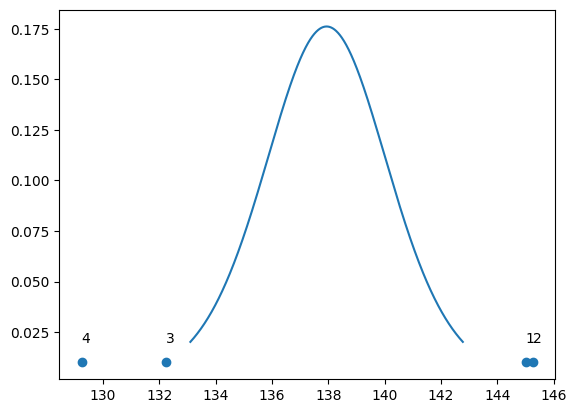

In [41]:
# e coating 2 has the highest conductivity
# generate data to build the t distribution.
loc_06e = df_06['conductivity'].mean()
scale_06e = np.sqrt(MSE_06/4) # 4 means each sample size is 4. degree of freedom of is the same as that of MSE_06, 12

x_06e = np.linspace(stats.t.isf(0.975, loc=loc_06e, scale=scale_06e, df=12), stats.t.isf(0.025, loc=loc_06e, scale=scale_06e, df=12), 1001) # covers 95% confidence interval
y_06e = stats.t.pdf(x_06e,loc=loc_06e, scale=scale_06e, df=12)

# plot
plt.plot(x_06e, y_06e)
plt.scatter(df_06.groupby('coating')['conductivity'].mean(), [0.01]*4)
for i in range(4):
    plt.text(df_06.groupby('coating')['conductivity'].mean().values[i], 0.02, df_06.groupby('coating')['conductivity'].mean().index[i])
plt.show()

In [42]:
# f keep using type 4

### Problem 7

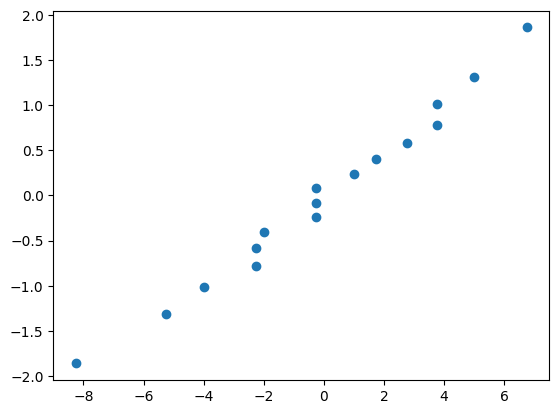

In [43]:
# plot residual - normality plot. no violatin of normality. the model above is adequte
plt.scatter(df_06.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,17)[:-1]+1/32))

In [44]:
# to use the *scipy.stats.f_oneway* method
def f_1way(df, by, measure, ):
    data = df.groupby(by)[measure].apply(list).values
    return stats.f_oneway(*data)

### Problem 8

In [45]:
df_08 = pd.DataFrame({
    'rodding': np.repeat([10,15,20,25],3),
    'strength': [1530,1530,1440,1610,1650,1500,1560,1730,1530,1500,1490,1510]
})

In [46]:
f_1way(df_08, 'rodding', 'strength')

F_onewayResult(statistic=np.float64(1.8653637350705747), pvalue=np.float64(0.21378148596410768))

In [47]:
# a and b: analysis of variance
df_08['ave'] = df_08['strength'].mean()
df_08['t_ave'] = df_08.groupby('rodding')['strength'].transform('mean')

df_08['t_dev'] = df_08['t_ave'] - df_08['ave']
df_08['residual'] = df_08['strength'] - df_08['t_ave']

SST_08 = (df_08.t_dev**2).sum() # sum of squares of treatment deviations, 3 degrees of freedom
MST_08 = SST_08/3 # mean square of treatment deviations, estimate of btw treatment variance

SSE_08 = (df_08.residual**2).sum() # sum of squares of residuals, 8 degrees of freedom
MSE_08 = SSE_08/8 # mean square of treatment deviations. estimate of test variance, within treatment variance

f_08 = MST_08/MSE_08 # f statistic, degrees of freedom, 3 and 8

p_08 = stats.f.sf(f_08, dfn=3, dfd=8)

print(f'The p value of the test is {p_08.round(3)}, larger than the pre-selected {alpha}=0.05. There is no significant difference in compressive strength dueto the rodding level.')

The p value of the test is 0.214, larger than the pre-selected α=0.05. There is no significant difference in compressive strength dueto the rodding level.


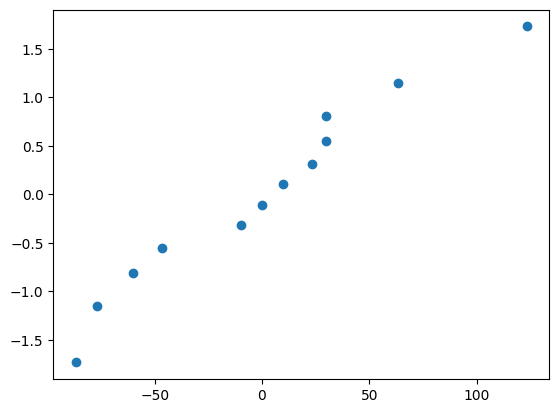

In [48]:
# c check residuals
# plot residual - normality plot. no violatin of normality. the model above is adequte
plt.scatter(df_08.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,13)[:-1]+1/24))

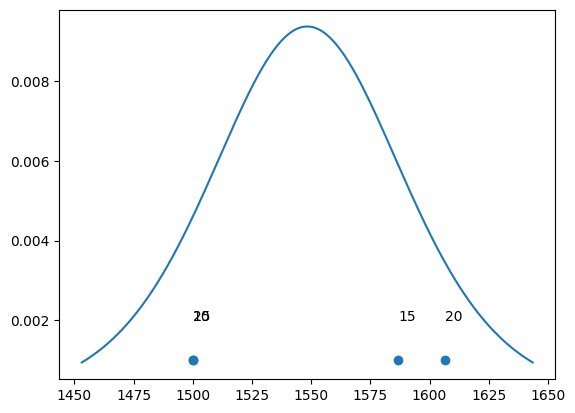

In [49]:
# d coating 2 has the highest conductivity
# generate data to build the t distribution.
loc_08 = df_08['strength'].mean()
scale_08 = np.sqrt(MSE_08/3) # 3 means each sample size is 3. degree of freedom of is the same as that of MSE_08, 8

x_08 = np.linspace(stats.t.isf(0.975, loc=loc_08, scale=scale_08, df=8), stats.t.isf(0.025, loc=loc_08, scale=scale_08, df=8), 1001) # covers 95% confidence interval
y_08 = stats.t.pdf(x_08,loc=loc_08, scale=scale_08, df=8)

# plot
plt.plot(x_08, y_08)
plt.scatter(df_08.groupby('rodding')['strength'].mean(), [0.001]*4)
for i in range(4):
    plt.text(df_08.groupby('rodding')['strength'].mean().values[i], 0.002, df_08.groupby('rodding')['strength'].mean().index[i])
plt.show()

### Example 1

### 

In [50]:
df_s01 = pd.DataFrame({
    'cotton': np.repeat(np.arange(5)*5+15,5),
    'strength': [7,7,15,11,9,12,17,12,18,18,14,18,18,19,19,19,25,22,19,23,7,10,11,15,11]
})

df_s01

,cotton,strength
0,15,7
1,15,7
2,15,15
3,15,11
4,15,9
5,20,12
6,20,17
7,20,12
8,20,18
9,20,18


In [51]:
data_s01 = df_s01.groupby('cotton')['strength'].apply(list).values
stats.f_oneway(data_s01[0], data_s01[1], data_s01[2], data_s01[3], data_s01[4])

F_onewayResult(statistic=np.float64(14.75682382133994), pvalue=np.float64(9.12793712405849e-06))

In [52]:
# a and b: analysis of variance
df_s01['ave'] = df_s01['strength'].mean()
df_s01['t_ave'] = df_s01.groupby('cotton')['strength'].transform('mean')

df_s01['t_dev'] = df_s01['t_ave'] - df_s01['ave']
df_s01['residual'] = df_s01['strength'] - df_s01['t_ave']

SST_s01 = (df_s01.t_dev**2).sum() # sum of squares of treatment deviations, 4 degrees of freedom
MST_s01 = SST_s01/4 # mean square of treatment deviations, estimate of btw treatment variance

SSE_s01 = (df_s01.residual**2).sum() # sum of squares of residuals, 20 degrees of freedom
MSE_s01 = SSE_s01/20 # mean square of treatment deviations. estimate of test variance, within treatment variance

f_s01 = MST_s01/MSE_s01 # f statistic, degrees of freedom, 4 and 20

p_s01 = stats.f.sf(f_s01, dfn=4, dfd=20)

print(f'The p value of the test is {p_s01.round(5)}, smaller than the pre-selected {alpha}=0.05. There is significant difference in compressive strength dueto the rodding level.')

The p value of the test is 1e-05, smaller than the pre-selected α=0.05. There is significant difference in compressive strength dueto the rodding level.


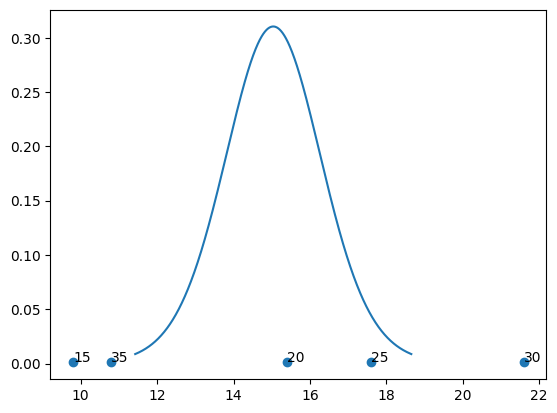

In [53]:
# generate data to build the t distribution.
loc_s01 = df_s01['strength'].mean()
scale_s01 = np.sqrt(MSE_s01/5) # 5 means each sample size is 5. degree of freedom of is the same as that of MSE_s01, 

x_s01 = np.linspace(stats.t.isf(0.995, loc=loc_s01, scale=scale_s01, df=20), stats.t.isf(0.005, loc=loc_s01, scale=scale_s01, df=20), 1001) # covers 95% confidence interval
y_s01 = stats.t.pdf(x_s01,loc=loc_s01, scale=scale_s01, df=20)

# plot
plt.plot(x_s01, y_s01)
plt.scatter(df_s01.groupby('cotton')['strength'].mean(), [0.001]*5)
for i in range(5):
    plt.text(df_s01.groupby('cotton')['strength'].mean().values[i], 0.002, df_s01.groupby('cotton')['strength'].mean().index[i])
plt.show()

### Problem 9

* from problem 9, I am going to just use the **scipy.stats.f_oneway** method

In [54]:
df_09 = pd.DataFrame({
    'dia': np.repeat([0.37,0.51,0.71,1.02,1.40,1.99],4),
    'radon': [80,83,83,85,75,75,79,79,74,73,76,77,67,72,74,74,62,62,67,69,60,61,64,66]
})

In [56]:
# a analysis of variance
f_09, p_09 = f_1way(df_09, 'dia', 'radon')
print(f'The p value for the test is <{1e-7}, smaller than the pre-selected {alpha}=0.05. The size of the orifice affect the mean precentage of radon released.')

The p value for the test is <1e-07, smaller than the pre-selected α=0.05. The size of the orifice affect the mean precentage of radon released.


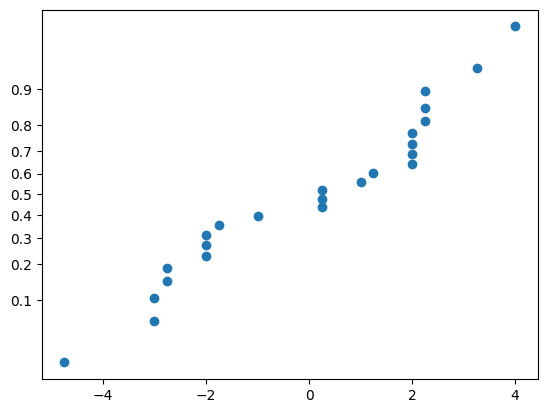

In [ ]:
# c check residuals with normality plot
# The plot shows no violations of normality
df_09['t_ave'] = df_09.groupby('dia')['radon'].transform('mean')
df_09['residual'] = df_09['radon'] - df_09['t_ave']

plt.scatter(df_09.residual.sort_values(), -stats.norm.isf(np.linspace(0,1,25)[:-1]+1/48))
plt.yticks(-stats.norm.isf(np.linspace(0.1,0.9,9)), np.linspace(0.1,0.9,9).round(2))
plt.show()

In [69]:
# d 
r_ave_09d = df_09[df_09['dia']==1.40]['radon'].mean() # the mean percent of radon released wht the diameter is 1.40
r_se_09d = np.sqrt((df_09.residual**2).sum()/(24-6)/4) # the standard error of the mean, with 18 degrees of freedom
t_09d = stats.t.sf(0.05/2, df=18) # the corresponding t statistic at right tail
print(f'The 95% confidence interval on the mean is from {(r_ave_09d-t_09d*r_se_09d).round(1)} to {(r_ave_09d + t_09d*r_se_09d).round(1)}')

The 95% confidence interval on the mean is from 64.3 to 65.7


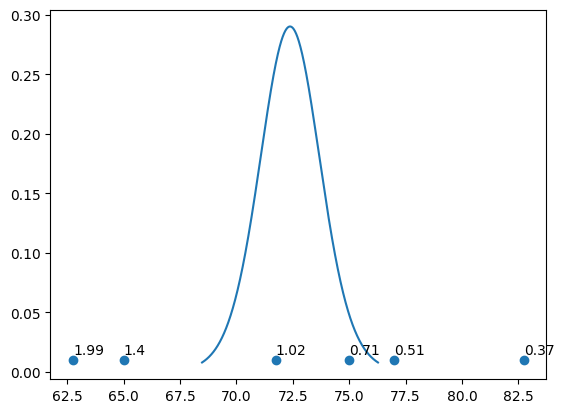

In [77]:
# e
# generate the data to plot the t distribution
loc_09e = df_09.radon.mean() # the center of the t distribution
scale_09e = r_se_09d # the scale of the t distribution is just the standard error of the sample mean

# create a range of x 
pct_09e = 0.99 # the coverage of the range x
t_09e = stats.t.isf((1-pct_09e)/2, scale=scale_09e, df=18) # 
x_09e = np.linspace(-t_09e, t_09e, 1001)
y_09e = stats.t.pdf(x_09e, scale=scale_09e, df=18)

# generate the t distribution plot
plt.plot(x_09e+loc_09e, y_09e)

# plot the data scatter plots
r_ave_09 = df_09.groupby('dia')['radon'].mean()
plt.scatter(r_ave_09.values, [0.01]*6)
for i in range(6):
    plt.text(r_ave_09.values[i], 0.015, r_ave_09.index[i])

### Problem 10

In [78]:
df_10 = pd.DataFrame({
    'circuit': np.repeat([1,2,3],5),
    'r_time': [9,12,10,8,15,20,21,23,17,30,6,5,8,16,7]
})

In [89]:
# a. The null hypothesis (H0): the three circuit types have the same response time and alpha=0.01
# run analysis of variance using the scipy.stats.f_oneway method
f_10a, p_10a = f_1way(df_10, 'circuit', 'r_time')
f_10a, p_10a
print(f'The p value of the test is {p_10a.round(4)}, smaller than the pre-selected {alpha}=0.01. The null hypothesis is safe to reject.')

The p value of the test is 0.0004, smaller than the pre-selected α=0.01. The null hypothesis is safe to reject.


In [ ]:
# b. Tukey's test with equal sample sizes
def tukey(df):
    